# Fold 1 Full Experiment

This notebook reuses the official FoldFlow backbone, the cached ESM embeddings, the existing LOKO fold 1 split, and the conditioning/CFG infrastructure already implemented in the repository.

This notebook retrains fold 1 from scratch when executed. It uses the official FoldFlow checkpoint and the existing fold-1 split, then writes fresh metrics, checkpoints, figures, and reports into the fold-1 artifact directories.

In [12]:
from __future__ import annotations

import json
import math
import os
import random
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from IPython.display import Image, display


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'train_single_fold.py').exists():
            return candidate
    raise FileNotFoundError('Could not locate the repository root')


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
if hasattr(torch.backends, 'cudnn'):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except TypeError:
    torch.use_deterministic_algorithms(True)

from models.foldflow_backbone import FoldFlowBackbone
from models.load_foldflow import DEFAULT_CHECKPOINT, OFFICIAL_REVISION
from kinase_data.translation import InactiveActiveTranslationDataset
from training.fold1_experiment import (
    Fold1TrainingConfig,
    build_model_and_loaders,
    build_optimizer,
    evaluate_test_loader,
    load_checkpoint,
    plot_prediction_comparison,
    plot_trajectory_snapshots,
    rmsd_from_coordinates,
    save_checkpoint,
    save_training_curves,
    select_example_sample,
    select_test_examples,
    structure_ca_coordinates,
    summarize_test_metrics,
    run_epoch,
    run_example_prediction,
    validation_cfg_diagnostics,
    write_metrics_csv,
)

REPORT_ROOT = PROJECT_ROOT / 'reports' / 'fold1'
FIGURE_ROOT = PROJECT_ROOT / 'figures' / 'fold1'
CHECKPOINT_ROOT = PROJECT_ROOT / 'checkpoints' / 'fold1'
EXAMPLE_ROOT = FIGURE_ROOT / 'examples'
TRAJECTORY_ROOT = FIGURE_ROOT / 'trajectory'
REPORT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)
EXAMPLE_ROOT.mkdir(parents=True, exist_ok=True)
TRAJECTORY_ROOT.mkdir(parents=True, exist_ok=True)

integration_report_path = PROJECT_ROOT / 'reports' / 'foldflow_integration_report.json'
summary_seed_path = REPORT_ROOT / 'summary.json'
integration_report = json.loads(integration_report_path.read_text()) if integration_report_path.exists() else {}
seed_summary = json.loads(summary_seed_path.read_text()) if summary_seed_path.exists() else {}

train_preview = InactiveActiveTranslationDataset(1, 'train', load_structures=False)
validation_preview = InactiveActiveTranslationDataset(1, 'validation', load_structures=False)
test_preview = InactiveActiveTranslationDataset(1, 'test', load_structures=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('FoldFlow revision:', OFFICIAL_REVISION)
print('Checkpoint path:', DEFAULT_CHECKPOINT)
print('FoldFlow parameters:', integration_report.get('parameter_count', {}).get('official_backbone', 'unknown'))
print('Conditioning parameters:', integration_report.get('parameter_count', {}).get('conditioning_adapter', 'unknown'))
print('Device:', device)
print('CUDA available:', torch.cuda.is_available())
print('Train / validation / test sizes:', len(train_preview), len(validation_preview), len(test_preview))

FoldFlow revision: 9d2c260813da3c9a2bc944973953f63ea6d71203
Checkpoint path: checkpoints/foldflow/foldflow-sfm.pth
FoldFlow parameters: 17446190
Conditioning parameters: 400640
Device: cpu
CUDA available: False
Train / validation / test sizes: 215 90 101


## Section 2 - Load Fold 1

In [13]:
fold_dir = PROJECT_ROOT / 'data' / 'folds' / 'fold_01'
train_fold_df = pd.read_csv(fold_dir / 'train.csv')
validation_fold_df = pd.read_csv(fold_dir / 'validation.csv')
test_fold_df = pd.read_csv(fold_dir / 'test.csv')

train_translation = train_preview
validation_translation = validation_preview
test_translation = test_preview

kinase_summary = pd.DataFrame([
    {
        'split': 'train',
        'pairs': len(train_translation),
        'kinase_counts': train_fold_df['kinase'].value_counts().sort_index().to_dict(),
        'active': int((train_fold_df['conformational_state'] == 'active').sum()),
        'inactive': int((train_fold_df['conformational_state'] == 'inactive').sum()),
    },
    {
        'split': 'validation',
        'pairs': len(validation_translation),
        'kinase_counts': validation_fold_df['kinase'].value_counts().sort_index().to_dict(),
        'active': int((validation_fold_df['conformational_state'] == 'active').sum()),
        'inactive': int((validation_fold_df['conformational_state'] == 'inactive').sum()),
    },
    {
        'split': 'test',
        'pairs': len(test_translation),
        'kinase_counts': test_fold_df['kinase'].value_counts().sort_index().to_dict(),
        'active': int((test_fold_df['conformational_state'] == 'active').sum()),
        'inactive': int((test_fold_df['conformational_state'] == 'inactive').sum()),
    },
])

display(kinase_summary)
display(train_fold_df.groupby(['kinase', 'conformational_state']).size().unstack(fill_value=0))
display(validation_fold_df.groupby(['kinase', 'conformational_state']).size().unstack(fill_value=0))
display(test_fold_df.groupby(['kinase', 'conformational_state']).size().unstack(fill_value=0))

pair_counts = pd.DataFrame([
    {'split': 'train', 'translation_pairs': len(train_translation)},
    {'split': 'validation', 'translation_pairs': len(validation_translation)},
    {'split': 'test', 'translation_pairs': len(test_translation)},
])
display(pair_counts)

,split,pairs,kinase_counts,active,inactive
0,train,215,"{'ABL1': 158, 'AKT1': 62, 'ALK': 95, 'CDK4': 1...",553,416
1,validation,90,{'BRAF': 243},58,185
2,test,101,{'EGFR': 565},221,344


conformational_state,active,inactive
kinase,,
ABL1,35,123
AKT1,38,24
ALK,91,4
CDK4,3,14
CDK6,5,16
ERBB2,8,6
FGFR1,211,6
KIT,18,51
MET,9,156


conformational_state,active,inactive
kinase,,
BRAF,58,185


conformational_state,active,inactive
kinase,,
EGFR,221,344


,split,translation_pairs
0,train,215
1,validation,90
2,test,101


## Section 3 - Model Construction

In [14]:
max_epochs = 10
early_stopping_patience = 15
learning_rate = float(os.environ.get('FOLD1_LR', '1e-4'))
weight_decay = 1e-4
gradient_clip = 1.0
cfg_dropout_probability = 0.2
guidance_scale = 2.0
batch_size = 1
num_workers = 0
reverse_steps = 6
reverse_min_t = 0.0
force_train = True

training_config = Fold1TrainingConfig(
    fold_id=1,
    epochs=max_epochs,
    batch_size=batch_size,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    grad_clip=gradient_clip,
    patience=early_stopping_patience,
    cfg_dropout_probability=cfg_dropout_probability,
    guidance_scale=guidance_scale,
    unfreeze_backbone=False,
    num_workers=num_workers,
    reverse_steps=reverse_steps,
    reverse_min_t=reverse_min_t,
    checkpoint_root=CHECKPOINT_ROOT,
    report_root=REPORT_ROOT,
    figure_root=FIGURE_ROOT,
)

model, train_loader, validation_loader, test_loader, fold_sizes = build_model_and_loaders(
    training_config,
    device,
)

trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
frozen_parameters = sum(parameter.numel() for parameter in model.parameters() if not parameter.requires_grad)
print('Trainable parameters:', trainable_parameters)
print('Frozen parameters:', frozen_parameters)
print('Official backbone frozen:', not any(parameter.requires_grad for parameter in model.official_model.parameters()))
print('Conditioning dimensions:', model.condition_encoder.dimensions)

Trainable parameters: 400640
Frozen parameters: 17446190
Official backbone frozen: True
Conditioning dimensions: ConditionDimensions(esm_input=1280, foldflow_node=256, kinase=256, state=256)


## Section 4 - Training Configuration

In [15]:
print(training_config)
print('Checkpoint directory:', training_config.checkpoint_root)
print('Report directory:', training_config.report_root)
print('Figure directory:', training_config.figure_root)
print('Force train:', force_train)

Fold1TrainingConfig(fold_id=1, epochs=10, batch_size=1, learning_rate=0.0001, weight_decay=0.0001, grad_clip=1.0, patience=15, cfg_dropout_probability=0.2, guidance_scale=2.0, unfreeze_backbone=False, num_workers=0, reverse_steps=6, reverse_min_t=0.0, checkpoint_root=PosixPath('/Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/checkpoints/fold1'), report_root=PosixPath('/Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/reports/fold1'), figure_root=PosixPath('/Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/figures/fold1'), source_root=None, official_checkpoint=PosixPath('checkpoints/foldflow/foldflow-sfm.pth'), validate_example_index=0)
Checkpoint directory: /Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/checkpoints/fold1
Report directory: /Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/reports/fold1
Figure directory: /Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/figures/fold1
Force train: True


## Section 5 - Training Loop

In [16]:
metrics_csv_path = REPORT_ROOT / 'training_metrics.csv'
best_checkpoint_path = CHECKPOINT_ROOT / 'best_validation.pt'
last_checkpoint_path = CHECKPOINT_ROOT / 'last.pt'

metrics_rows = []
best_validation_loss = float('inf')
best_epoch = 0
early_stopping_epoch = None

if force_train or not (metrics_csv_path.exists() and best_checkpoint_path.exists() and last_checkpoint_path.exists()):
    optimizer = build_optimizer(model, training_config)
    no_improvement = 0
    start_time = time.perf_counter()
    for epoch in range(1, max_epochs + 1):
        train_metrics = run_epoch(
            model,
            train_loader,
            device,
            cfg_dropout_probability,
            optimizer=optimizer,
            grad_clip=gradient_clip,
        )
        validation_metrics = run_epoch(
            model,
            validation_loader,
            device,
            cfg_dropout_probability,
            optimizer=None,
        )
        row = {
            'epoch': epoch,
            'train_total_loss': train_metrics['total_loss'],
            'train_rotation_loss': train_metrics['rotation_loss'],
            'train_translation_loss': train_metrics['translation_loss'],
            'validation_total_loss': validation_metrics['total_loss'],
            'validation_rotation_loss': validation_metrics['rotation_loss'],
            'validation_translation_loss': validation_metrics['translation_loss'],
        }
        metrics_rows.append(row)
        write_metrics_csv(metrics_rows, metrics_csv_path)
        save_checkpoint(
            last_checkpoint_path,
            model,
            optimizer,
            epoch,
            best_validation_loss,
            training_config,
            metrics=row,
            extra={'fold_sizes': fold_sizes},
        )
        if validation_metrics['total_loss'] < best_validation_loss:
            best_validation_loss = validation_metrics['total_loss']
            best_epoch = epoch
            no_improvement = 0
            save_checkpoint(
                best_checkpoint_path,
                model,
                optimizer,
                epoch,
                best_validation_loss,
                training_config,
                metrics=row,
                extra={'fold_sizes': fold_sizes},
            )
        else:
            no_improvement += 1
        print(
            f"epoch={epoch:03d} train={row['train_total_loss']:.4f} "
            f"val={row['validation_total_loss']:.4f} "
            f"rot={row['train_rotation_loss']:.4f}/{row['validation_rotation_loss']:.4f} "
            f"trans={row['train_translation_loss']:.4f}/{row['validation_translation_loss']:.4f}"
        )
        if no_improvement >= early_stopping_patience:
            early_stopping_epoch = epoch
            print(f'Early stopping triggered at epoch {epoch}')
            break
    training_duration = time.perf_counter() - start_time
else:
    metrics_df_existing = pd.read_csv(metrics_csv_path)
    metrics_rows = metrics_df_existing.to_dict('records')
    best_epoch = int(metrics_df_existing.loc[metrics_df_existing['validation_total_loss'].idxmin(), 'epoch'])
    best_validation_loss = float(metrics_df_existing['validation_total_loss'].min())
    early_stopping_epoch = int(metrics_df_existing['epoch'].iloc[-1])
    load_checkpoint(best_checkpoint_path, model)
    training_duration = 0.0
    print('Loaded existing training artifacts and best checkpoint.')

metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df)
print('Best validation loss:', best_validation_loss)
print('Best epoch:', best_epoch)
print('Early stopping epoch:', early_stopping_epoch)
print('Training duration (seconds):', training_duration)

/Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/third_party/foldflow_official/openfold/utils/tensor_utils.py:74: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:312.)
  return data[ranges]


epoch=001 train=369.1458 val=306.8887 rot=2.6221/1.8888 trans=366.5237/304.9998


/Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/third_party/foldflow_official/openfold/utils/tensor_utils.py:74: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:312.)
  return data[ranges]


epoch=002 train=269.5951 val=267.0235 rot=3.2303/1.9665 trans=266.3648/265.0570


/Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/third_party/foldflow_official/openfold/utils/tensor_utils.py:74: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:312.)
  return data[ranges]


...

epoch=009 train=203.6791 val=218.7136 rot=4.4782/3.3866 trans=199.2009/215.3270


/Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/third_party/foldflow_official/openfold/utils/tensor_utils.py:74: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:312.)
  return data[ranges]


epoch=010 train=190.7213 val=220.4232 rot=4.2453/3.1276 trans=186.4760/217.2956


,epoch,train_total_loss,train_rotation_loss,train_translation_loss,validation_total_loss,validation_rotation_loss,validation_translation_loss
0,1,369.145812,2.622132,366.523680,306.888655,1.888848,304.999806
1,2,269.595090,3.230294,266.364796,267.023516,1.966474,265.057042
2,3,236.895097,3.575974,233.319123,252.377111,2.001938,250.375173
3,4,230.212361,3.964011,226.248350,244.777786,2.374785,242.403001
4,5,209.989518,4.695029,205.294489,240.117782,2.798374,237.319408
5,6,219.188903,4.280019,214.908884,234.725985,2.778847,231.947138
6,7,205.096449,4.435267,200.661182,224.917229,2.924872,221.992357
7,8,198.373034,4.613726,193.759308,225.059070,3.150904,221.908166
8,9,203.679078,4.478178,199.200900,218.713628,3.386618,215.327010
9,10,190.721345,4.245341,186.476004,220.423201,3.127586,217.295615


Best validation loss: 218.71362816693028
Best epoch: 9
Early stopping epoch: None
Training duration (seconds): 3438.5959841669974


## Section 6 - Training Curves

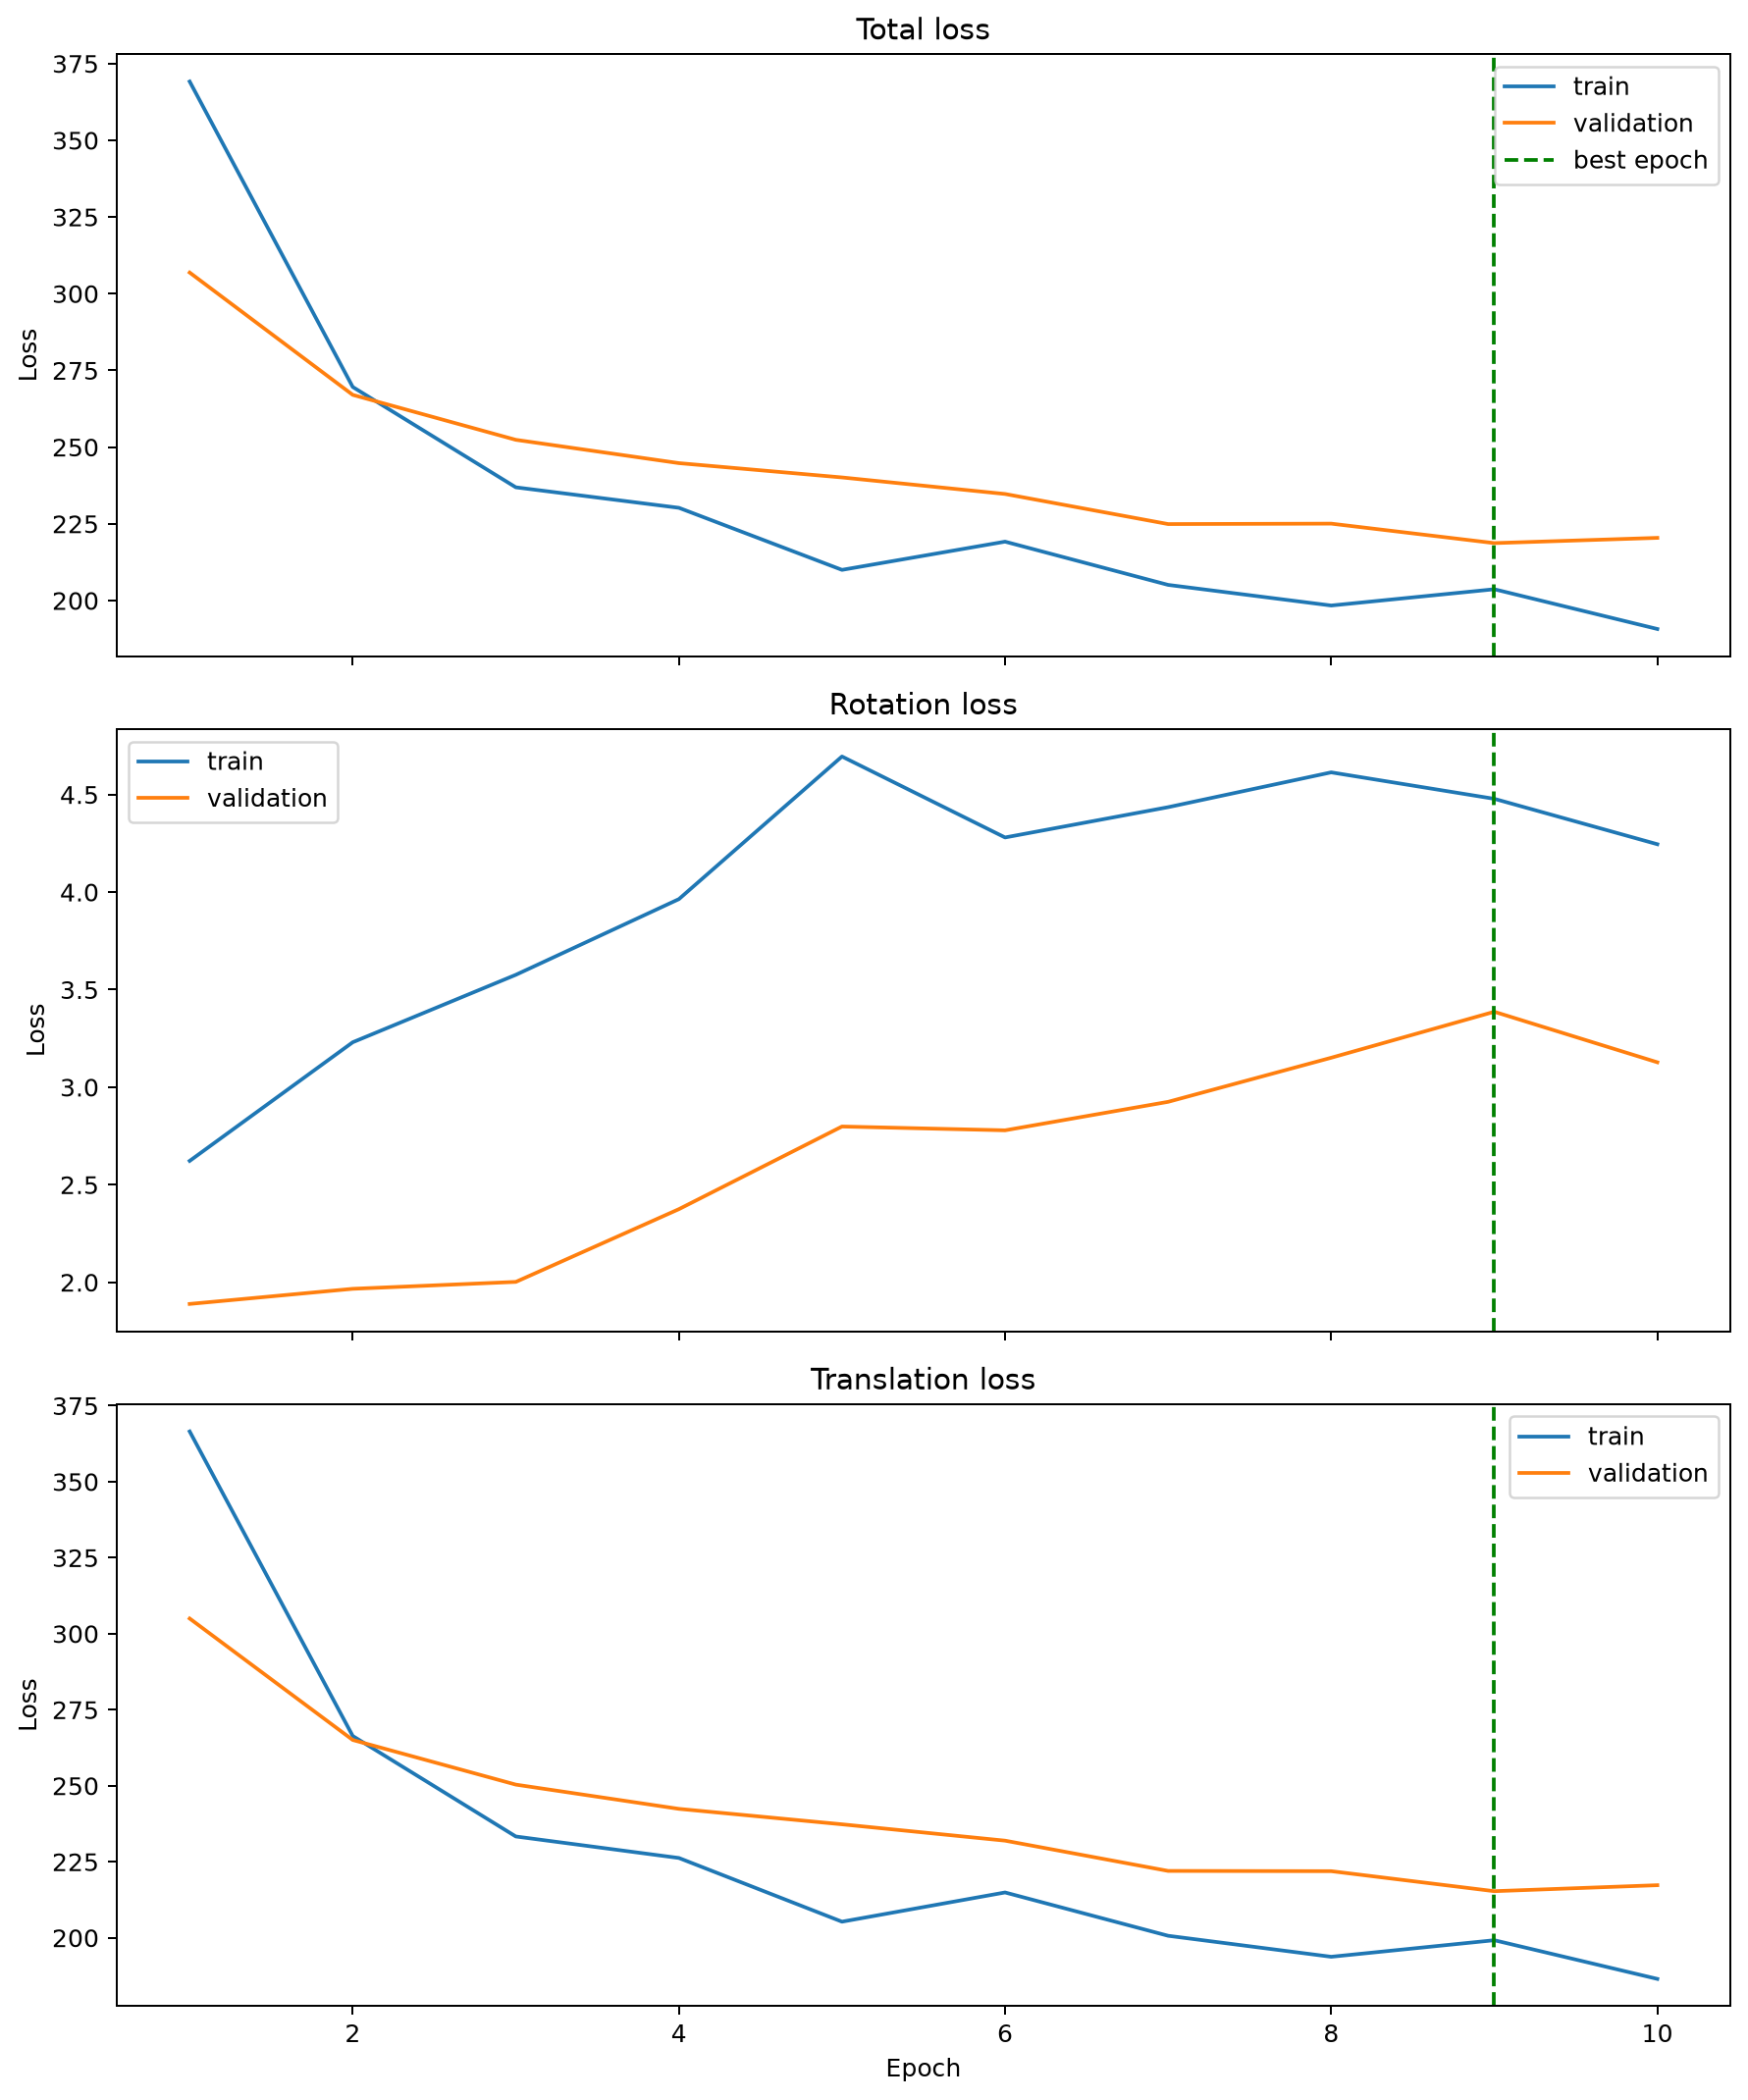

In [17]:
metrics_df = pd.read_csv(metrics_csv_path)
save_training_curves(metrics_csv_path, FIGURE_ROOT)

import matplotlib.pyplot as plt

figure, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
plots = [
    ('total', 'train_total_loss', 'validation_total_loss'),
    ('rotation', 'train_rotation_loss', 'validation_rotation_loss'),
    ('translation', 'train_translation_loss', 'validation_translation_loss'),
]
for axis, (title, train_col, validation_col) in zip(axes, plots):
    axis.plot(metrics_df['epoch'], metrics_df[train_col], label='train')
    axis.plot(metrics_df['epoch'], metrics_df[validation_col], label='validation')
    axis.axvline(best_epoch, color='green', linestyle='--', label='best epoch' if title == 'total' else None)
    if early_stopping_epoch is not None:
        axis.axvline(early_stopping_epoch, color='red', linestyle=':', label='early stopping' if title == 'total' else None)
    axis.set_title(f'{title.capitalize()} loss')
    axis.set_ylabel('Loss')
    axis.legend(loc='best')
axes[-1].set_xlabel('Epoch')
figure.tight_layout()
figure.savefig(FIGURE_ROOT / 'train_validation_losses.png', dpi=180, bbox_inches='tight')
plt.close(figure)

display(Image(filename=str(FIGURE_ROOT / 'train_validation_losses.png')))

## Section 7 - Overfitting Diagnostics

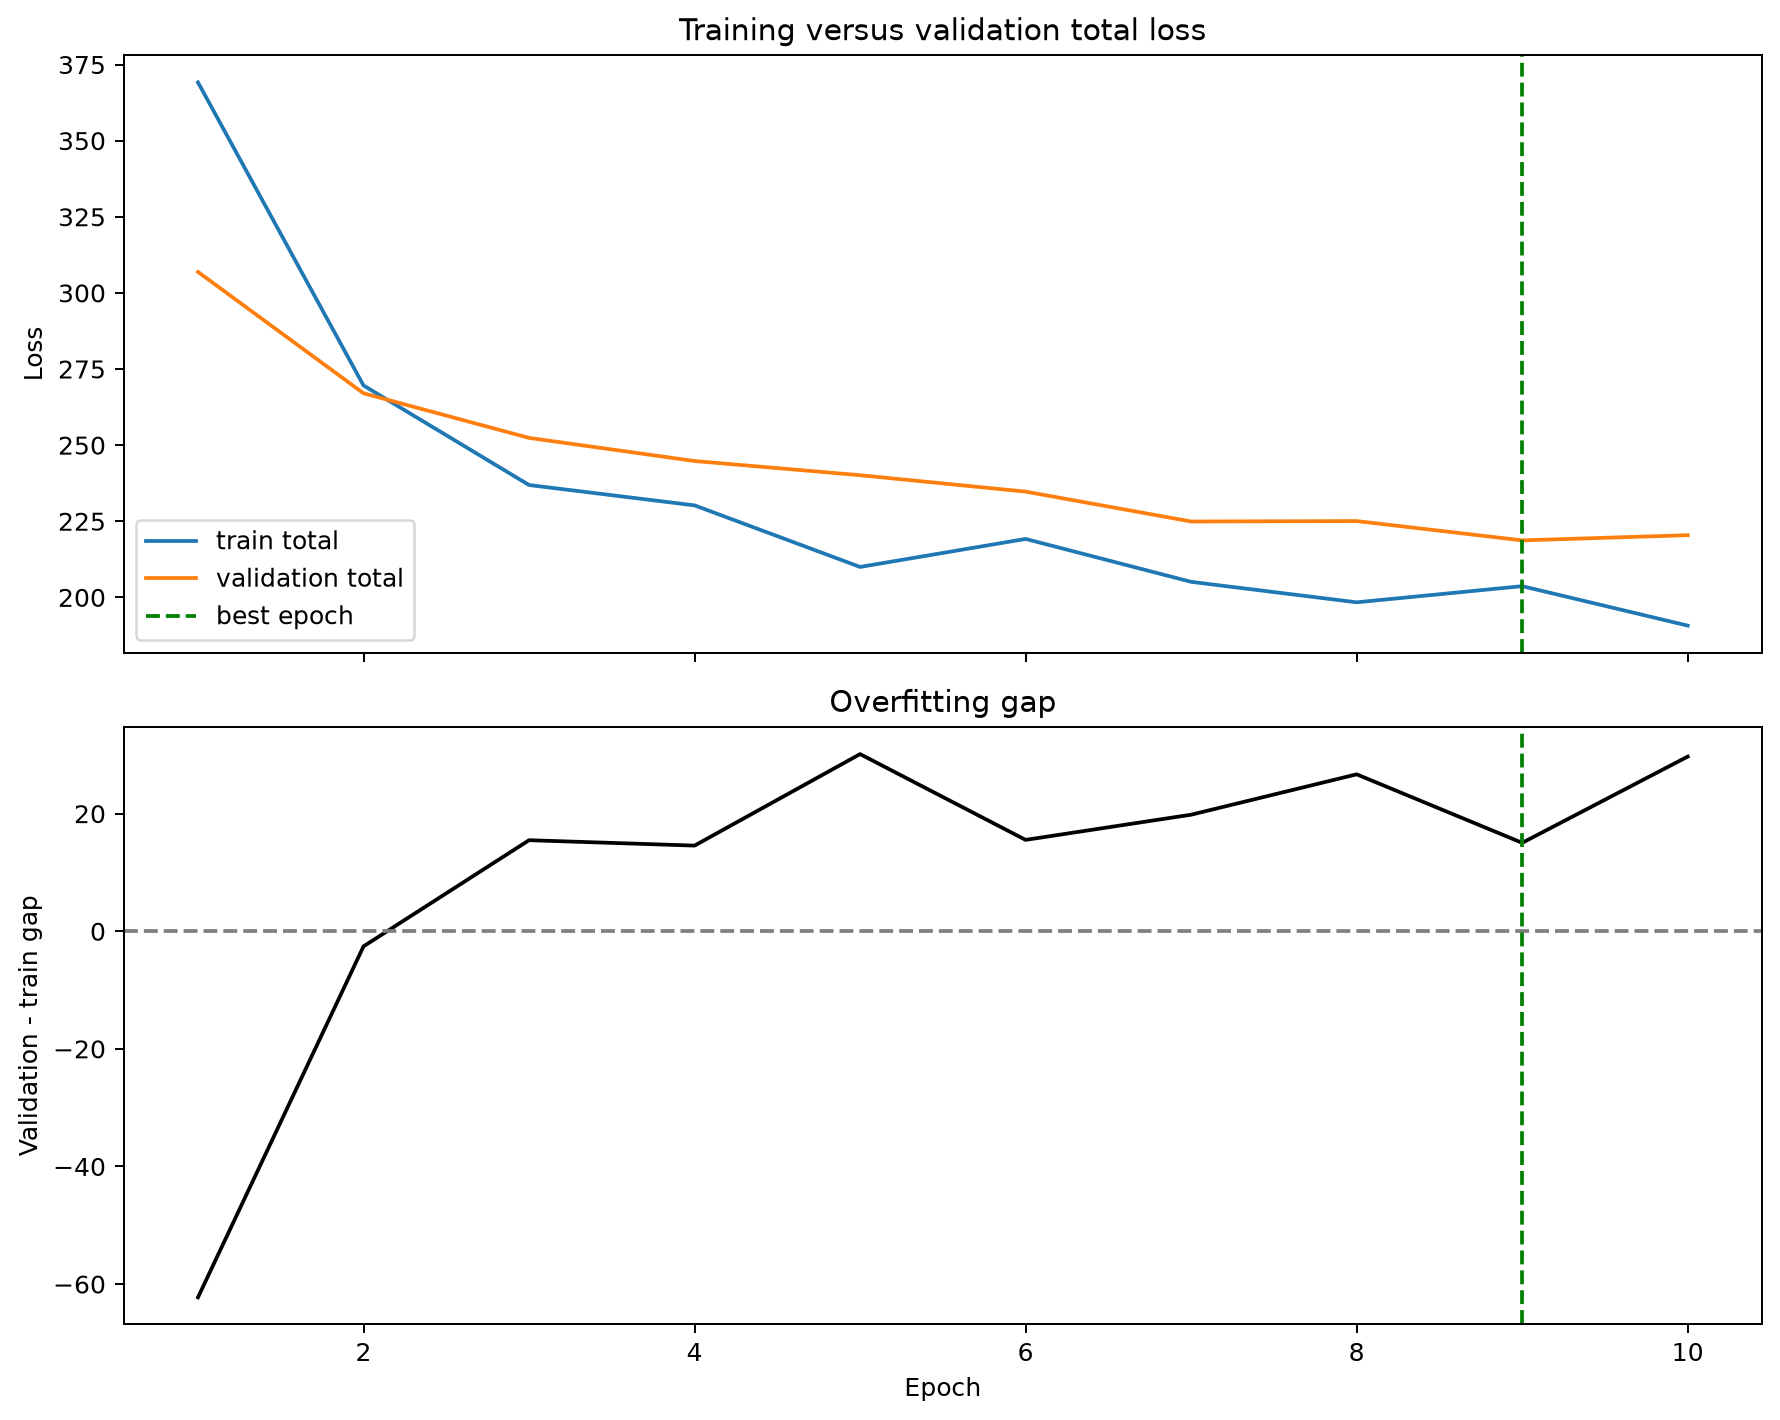

Final gap: 29.7019
Best gap: 15.0345
Overfitting observed:


In [18]:
metrics_df['train_validation_gap'] = metrics_df['validation_total_loss'] - metrics_df['train_total_loss']
figure, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(metrics_df['epoch'], metrics_df['train_total_loss'], label='train total')
axes[0].plot(metrics_df['epoch'], metrics_df['validation_total_loss'], label='validation total')
axes[0].axvline(best_epoch, color='green', linestyle='--', label='best epoch')
if early_stopping_epoch is not None:
    axes[0].axvline(early_stopping_epoch, color='red', linestyle=':', label='early stopping')
axes[0].set_ylabel('Loss')
axes[0].legend(loc='best')
axes[0].set_title('Training versus validation total loss')
axes[1].plot(metrics_df['epoch'], metrics_df['train_validation_gap'], color='black')
axes[1].axhline(0.0, color='gray', linestyle='--')
axes[1].axvline(best_epoch, color='green', linestyle='--')
if early_stopping_epoch is not None:
    axes[1].axvline(early_stopping_epoch, color='red', linestyle=':')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation - train gap')
axes[1].set_title('Overfitting gap')
figure.tight_layout()
figure.savefig(FIGURE_ROOT / 'overfitting_analysis.png', dpi=180, bbox_inches='tight')
plt.close(figure)

display(Image(filename=str(FIGURE_ROOT / 'overfitting_analysis.png')))
final_gap = float(metrics_df['train_validation_gap'].iloc[-1])
best_gap = float(metrics_df.loc[metrics_df['validation_total_loss'].idxmin(), 'train_validation_gap'])
overfitting_observed = final_gap > best_gap
print(f'Final gap: {final_gap:.4f}')
print(f'Best gap: {best_gap:.4f}')
print('Overfitting observed:' if overfitting_observed else 'No strong overfitting signal observed yet.')

## Section 8 - CFG Diagnostics

/Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/third_party/foldflow_official/openfold/utils/tensor_utils.py:74: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:312.)
  return data[ranges]


,guidance_scale,average_vectorfield_magnitude,average_prediction_difference,batches
0,0.0,6.523189,0.420627,90
1,1.0,6.537760,0.420627,90
2,3.0,7.201734,0.420627,90
3,5.0,8.204230,0.420627,90


INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


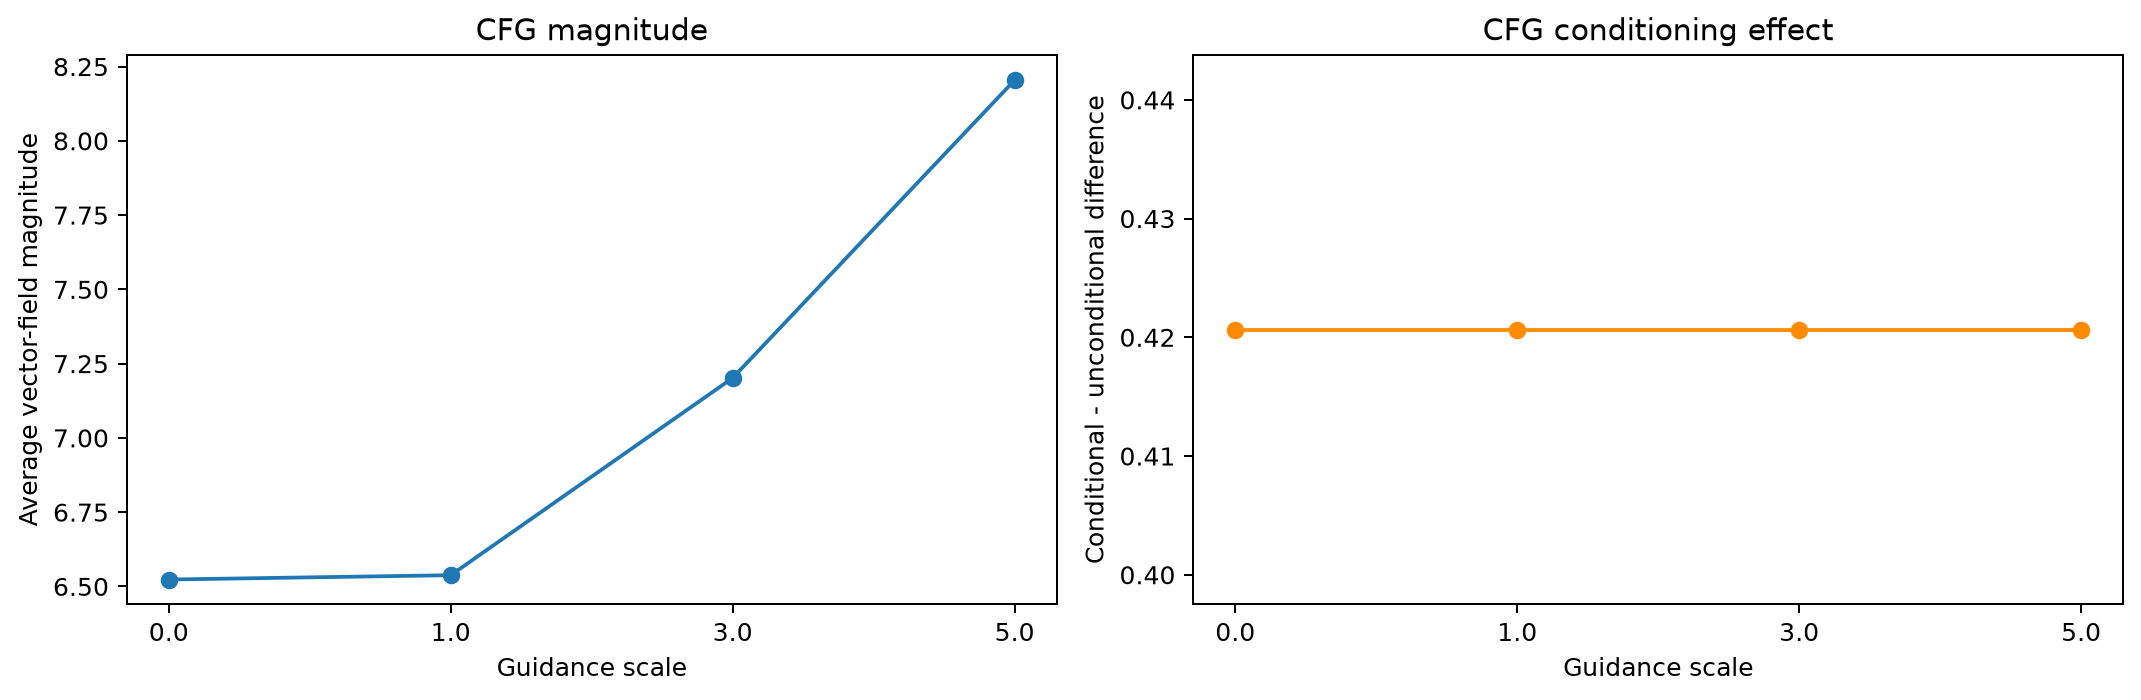

In [19]:
cfg_report_path = REPORT_ROOT / 'cfg_diagnostics.json'
if force_train or not cfg_report_path.exists():
    cfg_diagnostics = validation_cfg_diagnostics(
        model,
        validation_loader,
        device,
        guidance_scales=(0.0, 1.0, 3.0, 5.0),
    )
    cfg_report_path.write_text(json.dumps(cfg_diagnostics, indent=2) + '\n', encoding='utf-8')
else:
    cfg_diagnostics = json.loads(cfg_report_path.read_text())

cfg_frame = pd.DataFrame.from_dict(cfg_diagnostics, orient='index').reset_index(names='guidance_scale')
display(cfg_frame)

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cfg_frame['guidance_scale'], cfg_frame['average_vectorfield_magnitude'], marker='o')
axes[0].set_xlabel('Guidance scale')
axes[0].set_ylabel('Average vector-field magnitude')
axes[0].set_title('CFG magnitude')
axes[1].plot(cfg_frame['guidance_scale'], cfg_frame['average_prediction_difference'], marker='o', color='darkorange')
axes[1].set_xlabel('Guidance scale')
axes[1].set_ylabel('Conditional - unconditional difference')
axes[1].set_title('CFG conditioning effect')
figure.tight_layout()
figure.savefig(FIGURE_ROOT / 'cfg_diagnostics.png', dpi=180, bbox_inches='tight')
plt.close(figure)

display(Image(filename=str(FIGURE_ROOT / 'cfg_diagnostics.png')))

## Section 9 - Test Set Evaluation

In [20]:
load_checkpoint(best_checkpoint_path, model)

test_metrics_df = evaluate_test_loader(
    model,
    test_loader,
    device,
    guidance_scale=guidance_scale,
    num_steps=reverse_steps,
    min_t=reverse_min_t,
)
test_metrics_path = REPORT_ROOT / 'test_metrics.csv'
test_metrics_df.to_csv(test_metrics_path, index=False)
test_summary = summarize_test_metrics(test_metrics_df)
test_summary_path = REPORT_ROOT / 'test_summary.json'
test_summary_path.write_text(json.dumps(test_summary, indent=2) + '\n', encoding='utf-8')

display(test_metrics_df.head())
display(pd.DataFrame([test_summary]))

/Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/third_party/foldflow_official/openfold/utils/tensor_utils.py:74: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:312.)
  return data[ranges]


,sample_index,kinase,source_pdb_id,target_pdb_id,sequence_identity,residue_count,rmsd_source_target,rmsd_prediction_target,rmsd_improvement,successful_translation
0,0,EGFR,1xkk,4zau,0.988971,272,3.225520e+00,16.706137,-13.480617,False
1,1,EGFR,2gs7,7a6i,0.996403,278,4.232799e+00,17.998671,-13.765872,False
2,2,EGFR,2jit,2jit,1.000000,299,4.796637e-15,17.705850,-17.705850,False
3,3,EGFR,2jiu,2jiu,1.000000,309,4.706641e-15,18.485548,-18.485548,False
4,4,EGFR,2jiv,5gnk,0.996296,270,1.558159e+00,18.120644,-16.562485,False


,number_of_samples,mean_rmsd_source_target,mean_rmsd_prediction_target,mean_rmsd_improvement,median_rmsd_improvement,successful_translation_rate,successful_translations,median_sample_index
0,101,3.316142,17.074148,-13.758006,-13.765872,0.0,0,50


## Section 10 - Best Example Visualization

/Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/third_party/foldflow_official/openfold/utils/tensor_utils.py:74: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:312.)
  return data[ranges]


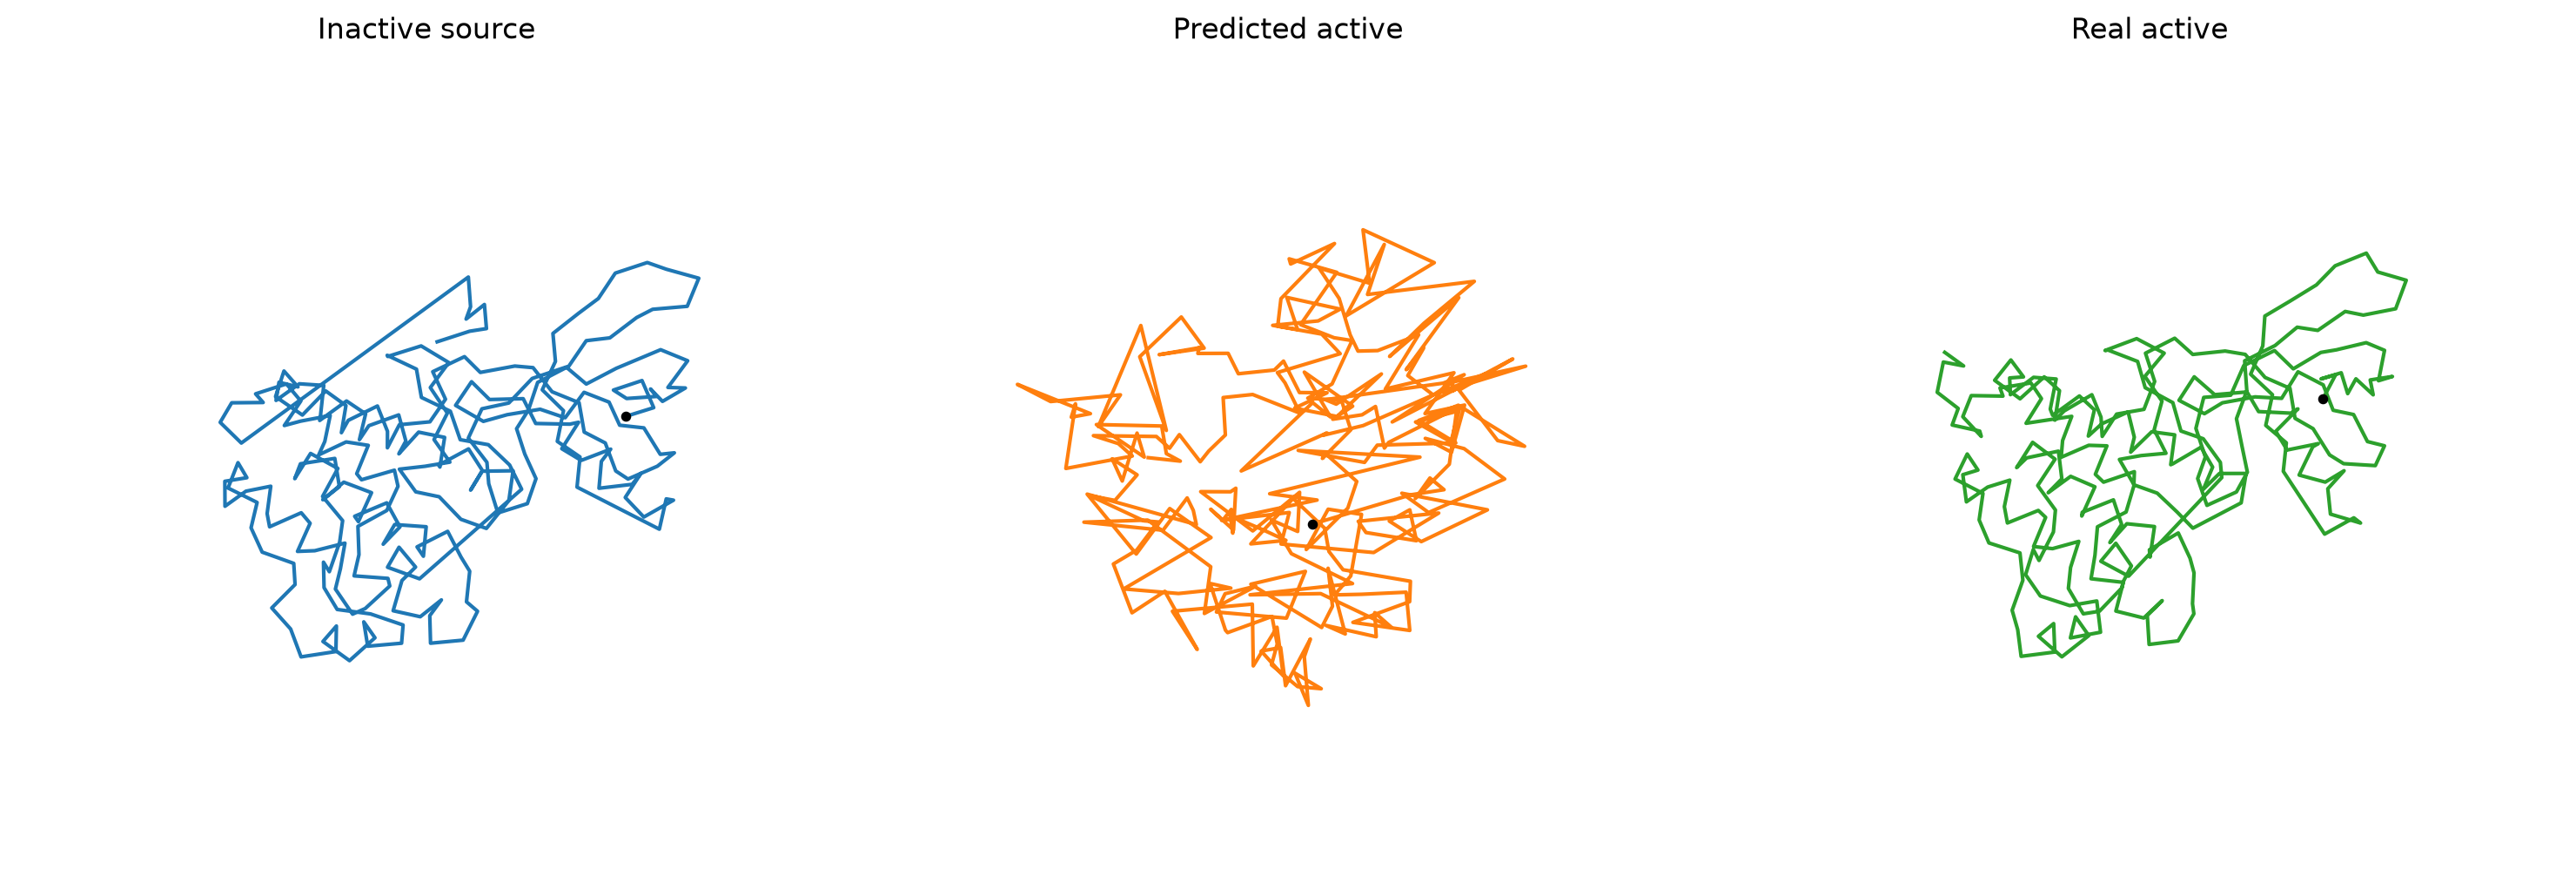

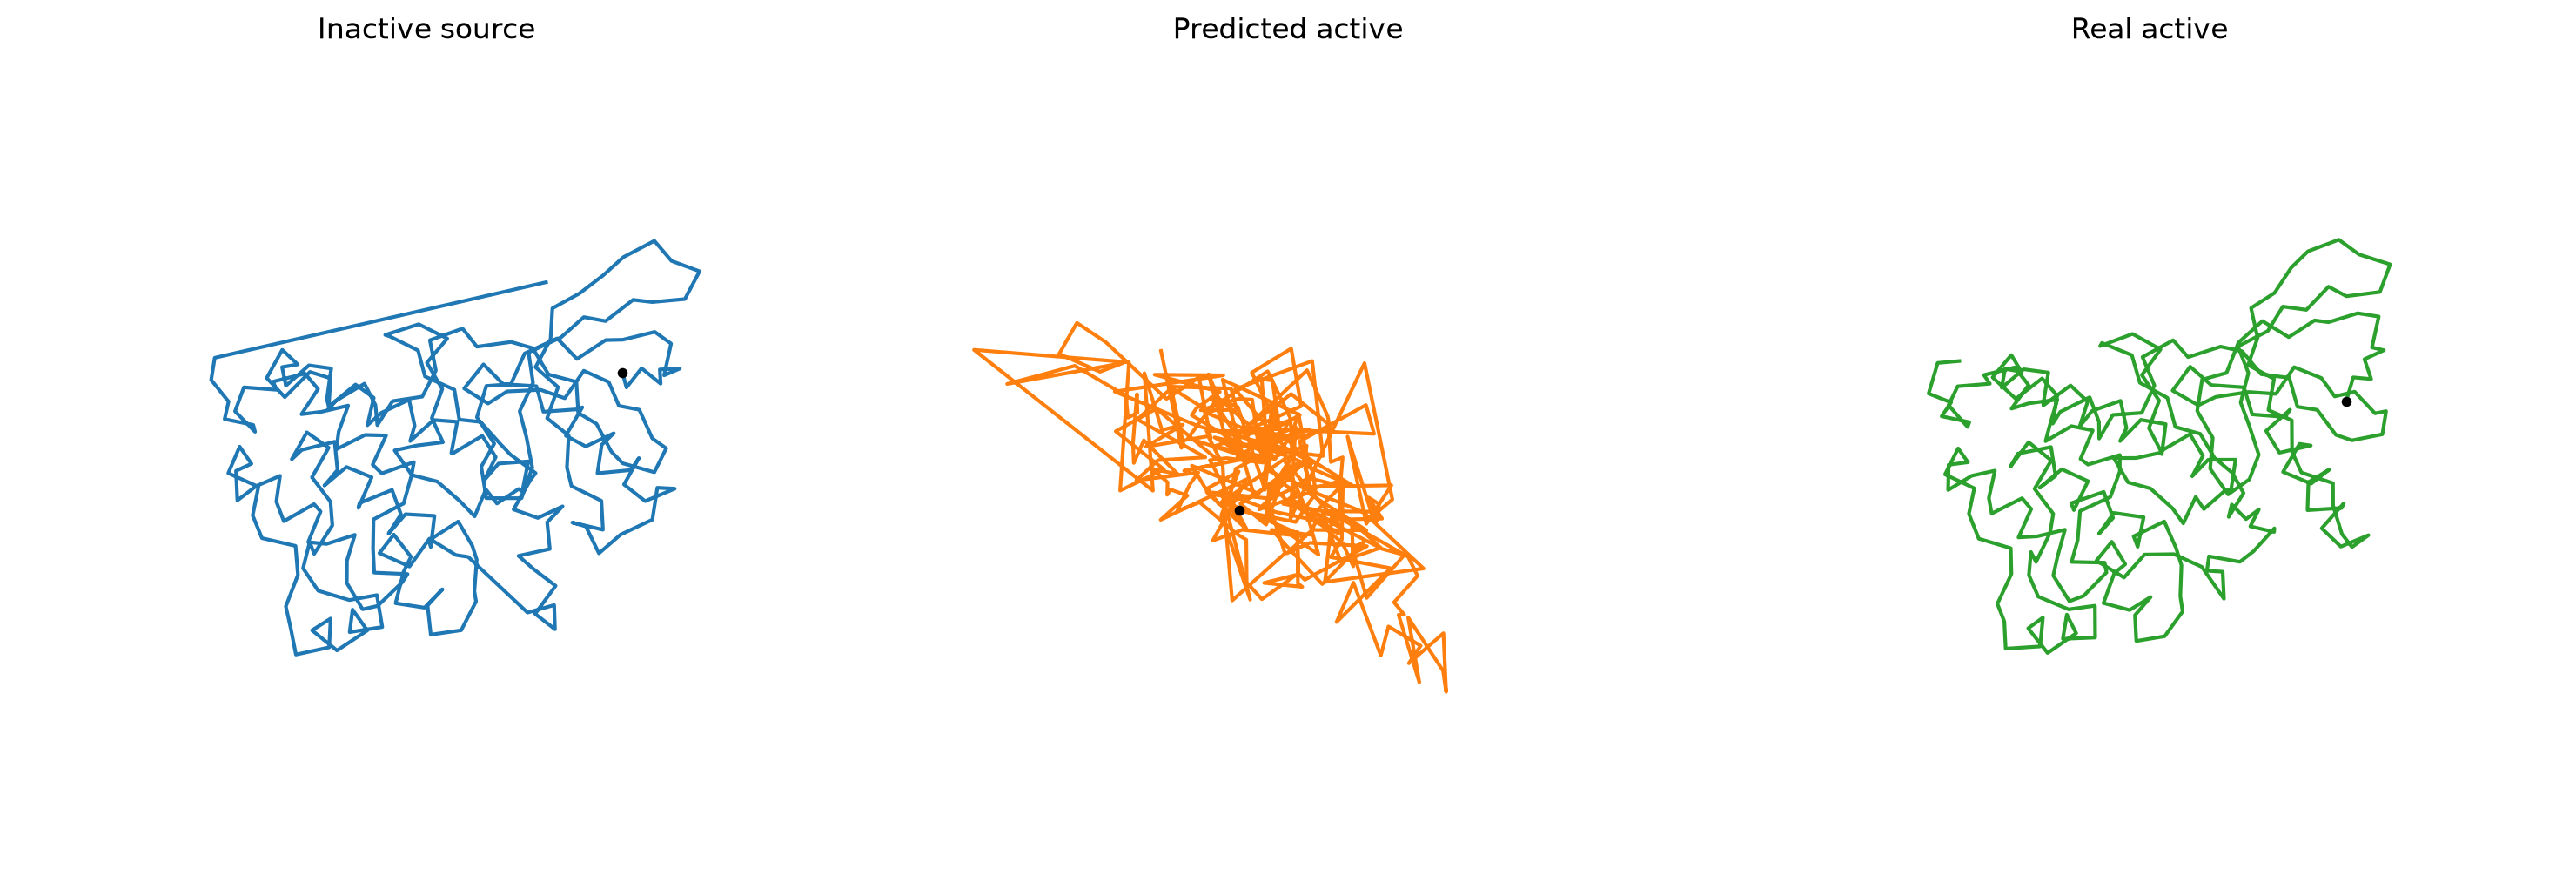

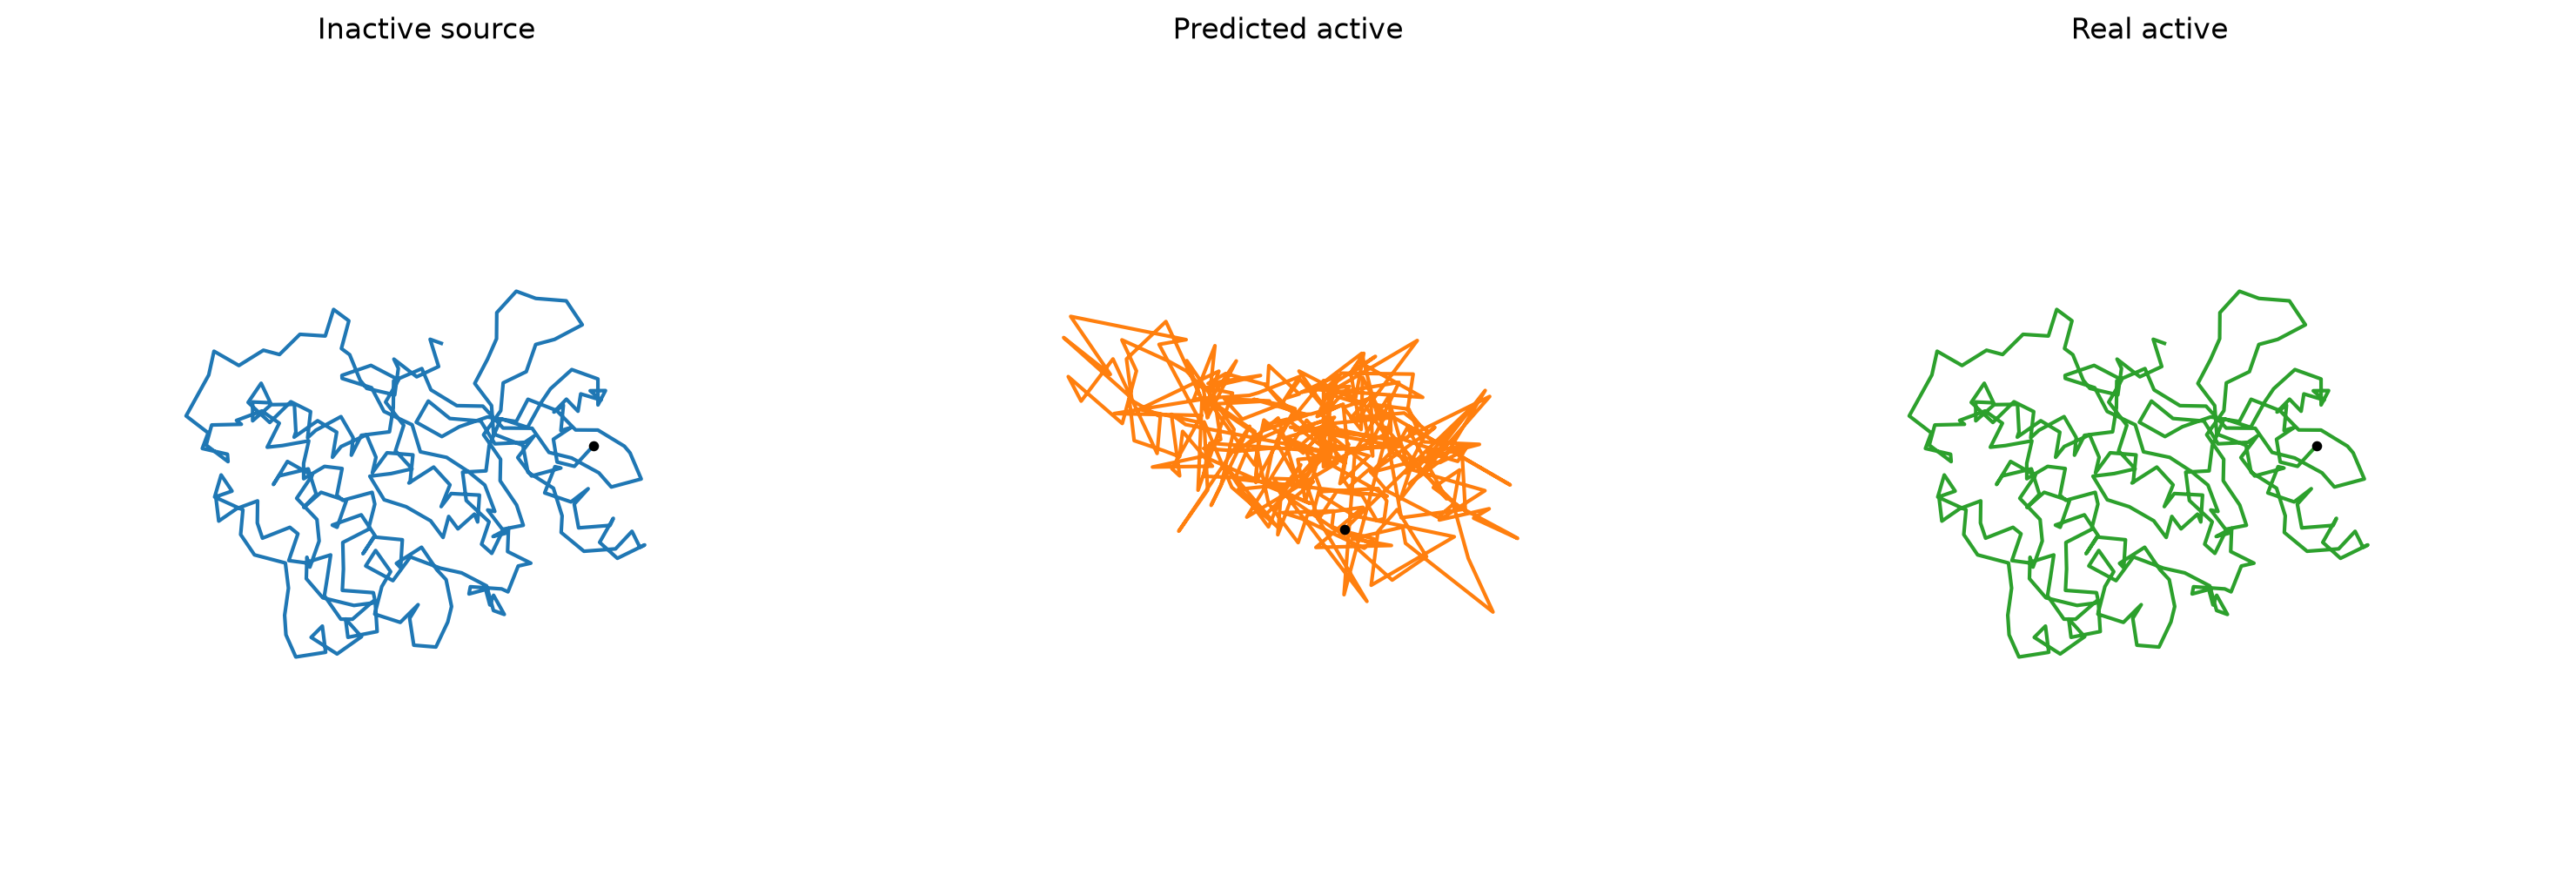

,example,kinase,source_pdb_id,target_pdb_id,rmsd_source_target,rmsd_prediction_target,rmsd_improvement
0,successful,EGFR,8eme,5gnk,5.043996e+00,12.766161,-7.722165
1,median,EGFR,2gs7,7a6i,4.232799e+00,17.998671,-13.765872
2,difficult,EGFR,2jiu,2jiu,4.706641e-15,18.485548,-18.485548


In [21]:
selected_examples = select_test_examples(test_metrics_df)
example_payloads = {}
example_tables = []
for label, row in selected_examples.items():
    sample = test_loader.dataset[int(row['sample_index'])]
    payload = run_example_prediction(
        model,
        sample,
        device,
        guidance_scale=guidance_scale,
        num_steps=reverse_steps,
        min_t=reverse_min_t,
    )
    example_payloads[label] = payload
    pt_path = REPORT_ROOT / 'examples' / f'{label}_prediction.pt'
    pt_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(payload, pt_path)
    figure_path = EXAMPLE_ROOT / f'{label}.png'
    plot_prediction_comparison(payload, figure_path)
    example_tables.append({
        'example': label,
        'kinase': sample['kinase'],
        'source_pdb_id': sample['source_pdb_id'],
        'target_pdb_id': sample['target_pdb_id'],
        'rmsd_source_target': float(row['rmsd_source_target']),
        'rmsd_prediction_target': float(row['rmsd_prediction_target']),
        'rmsd_improvement': float(row['rmsd_improvement']),
    })
    display(Image(filename=str(figure_path)))

display(pd.DataFrame(example_tables))

## Section 11 - Denoising Trajectory

/Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/third_party/foldflow_official/openfold/utils/tensor_utils.py:74: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:312.)
  return data[ranges]


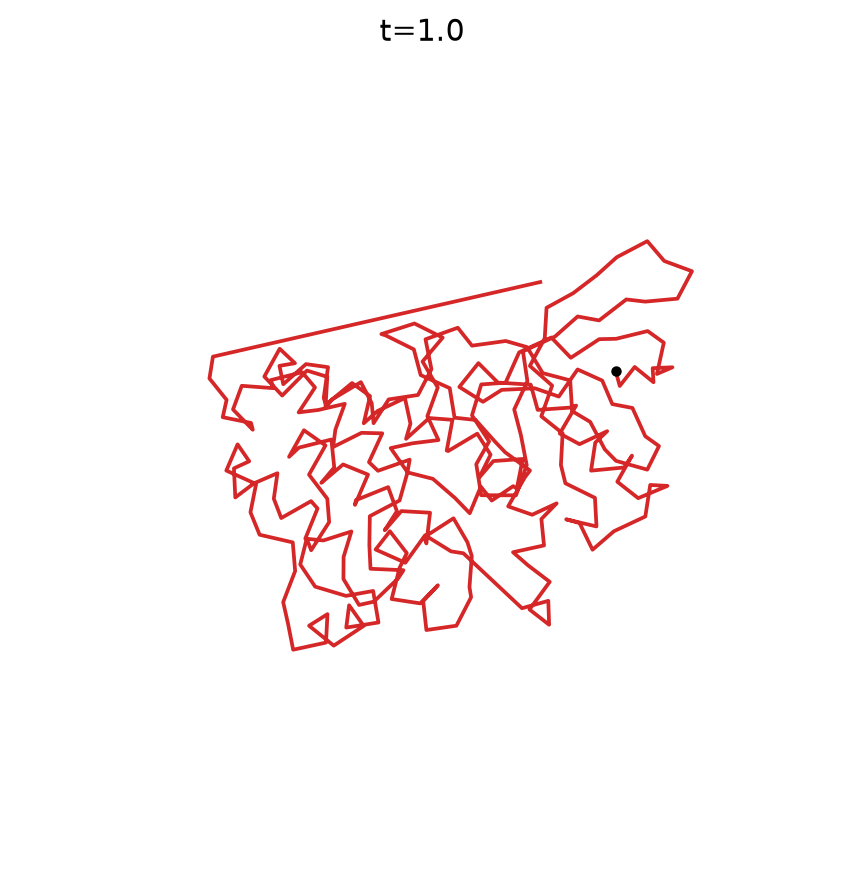

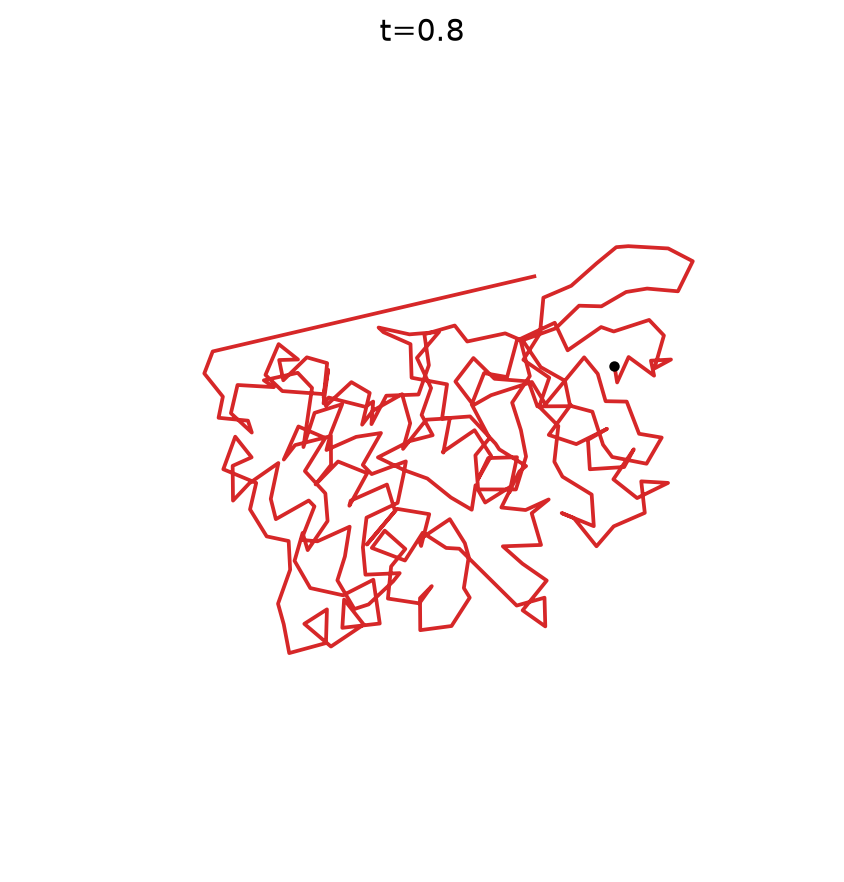

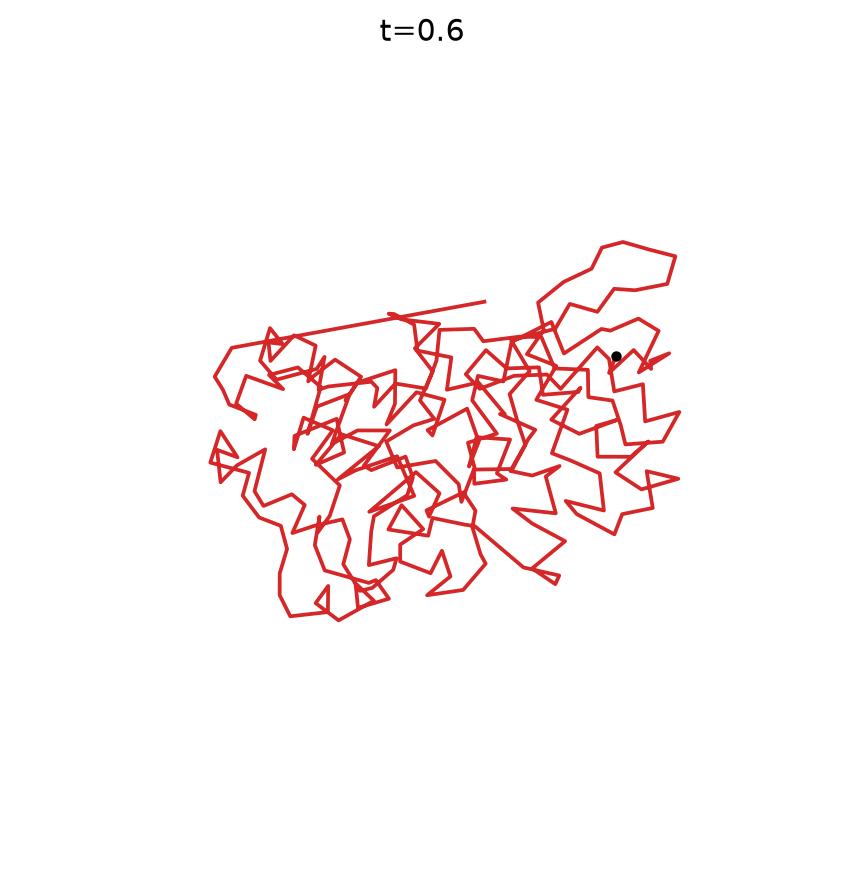

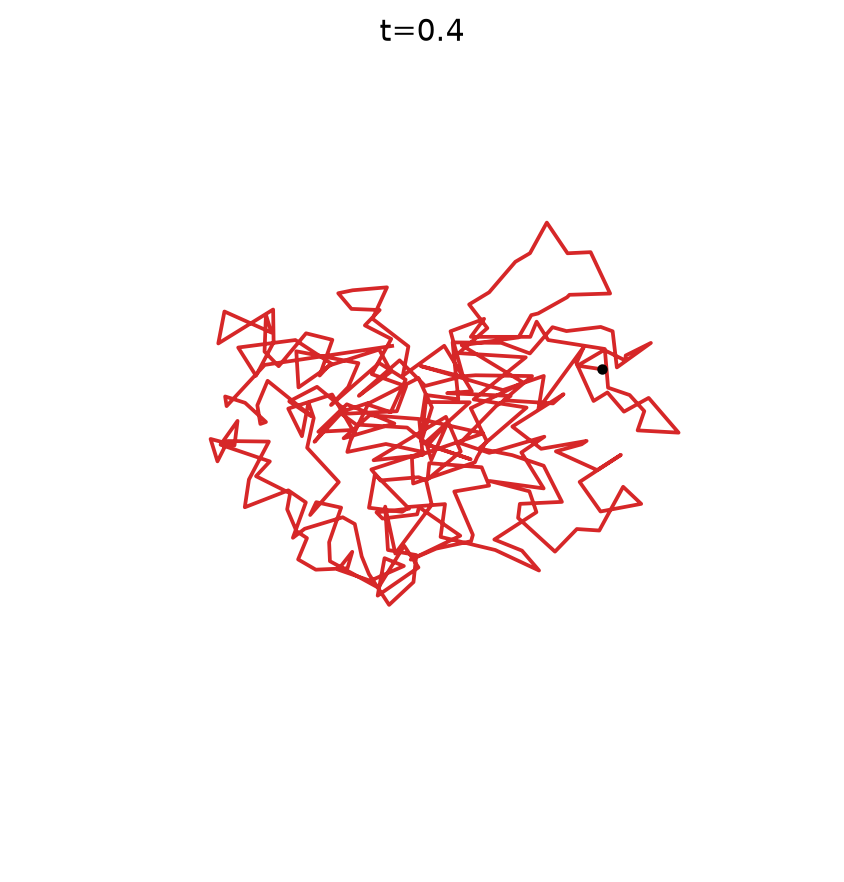

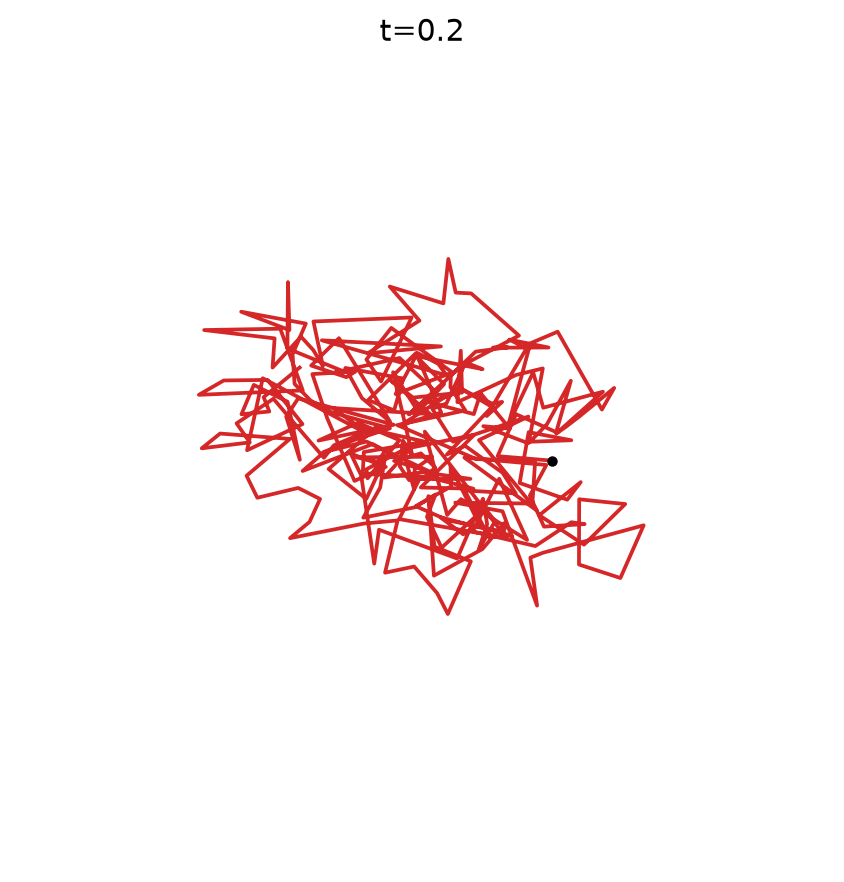

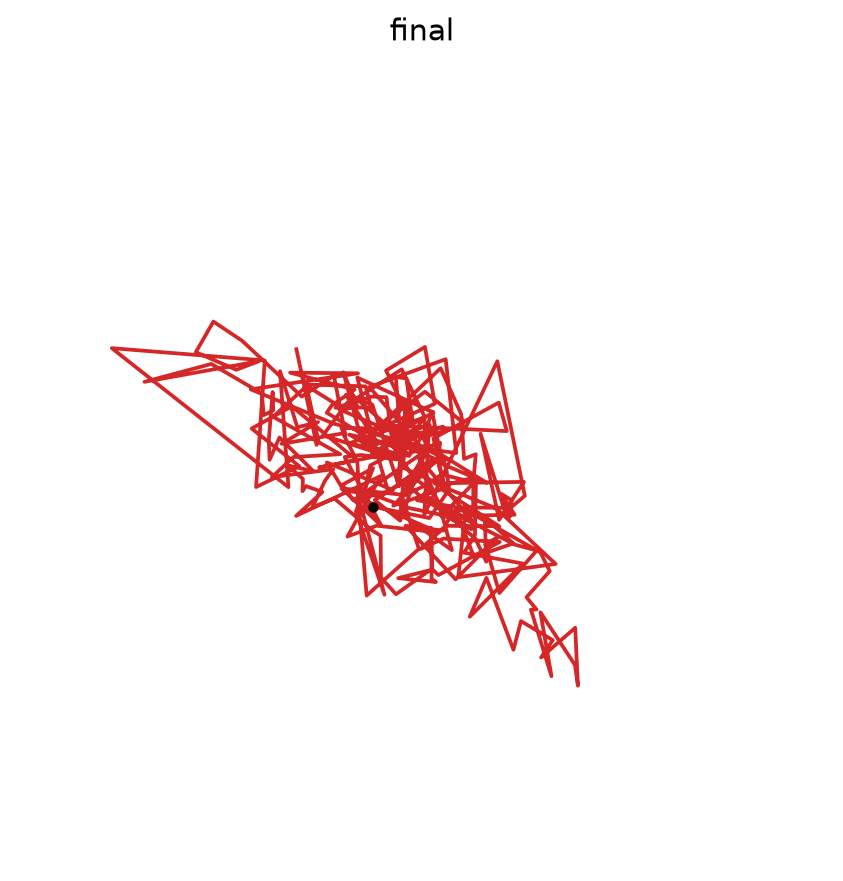

In [22]:
representative_row = selected_examples['median']
representative_sample = test_loader.dataset[int(representative_row['sample_index'])]
representative_payload = run_example_prediction(
    model,
    representative_sample,
    device,
    guidance_scale=guidance_scale,
    num_steps=reverse_steps,
    min_t=reverse_min_t,
)
trajectory_paths = plot_trajectory_snapshots(representative_payload, TRAJECTORY_ROOT)
for path in trajectory_paths:
    display(Image(filename=str(path)))

## Section 12 - Final Experiment Summary

In [23]:
final_report = {
    'fold_id': 1,
    'train_size': int(fold_sizes['train']),
    'validation_size': int(fold_sizes['validation']),
    'test_size': int(fold_sizes['test']),
    'best_validation_loss': float(best_validation_loss),
    'best_epoch': int(best_epoch),
    'total_epochs_trained': int(metrics_df['epoch'].iloc[-1]),
    'rmsd_source_target': float(test_summary['mean_rmsd_source_target']),
    'rmsd_prediction_target': float(test_summary['mean_rmsd_prediction_target']),
    'average_improvement': float(test_summary['mean_rmsd_improvement']),
    'median_improvement': float(test_summary['median_rmsd_improvement']),
    'conditioning_parameter_count': int(model.conditioning_parameter_count),
    'FoldFlow_parameter_count': int(model.official_parameter_count),
    'checkpoint_path': str(best_checkpoint_path),
    'last_checkpoint_path': str(last_checkpoint_path),
    'metrics_csv': str(metrics_csv_path),
    'test_metrics_csv': str(test_metrics_path),
    'test_summary_path': str(test_summary_path),
    'cfg_diagnostics_path': str(cfg_report_path),
}
final_report_path = REPORT_ROOT / 'final_report.json'
final_report_path.write_text(json.dumps(final_report, indent=2) + '\n', encoding='utf-8')

display(pd.DataFrame([final_report]))
print('Final report saved to', final_report_path)

,fold_id,train_size,validation_size,test_size,best_validation_loss,best_epoch,total_epochs_trained,rmsd_source_target,rmsd_prediction_target,average_improvement,median_improvement,conditioning_parameter_count,FoldFlow_parameter_count,checkpoint_path,last_checkpoint_path,metrics_csv,test_metrics_csv,test_summary_path,cfg_diagnostics_path
0,1,215,90,101,218.713628,9,10,3.316142,17.074148,-13.758006,-13.765872,400640,17446190,/Users/josefinadehan/tp_vision_avanzada/TPF_Vi...,/Users/josefinadehan/tp_vision_avanzada/TPF_Vi...,/Users/josefinadehan/tp_vision_avanzada/TPF_Vi...,/Users/josefinadehan/tp_vision_avanzada/TPF_Vi...,/Users/josefinadehan/tp_vision_avanzada/TPF_Vi...,/Users/josefinadehan/tp_vision_avanzada/TPF_Vi...


Final report saved to /Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/reports/fold1/final_report.json
